           id code        name      demonym
0      africa   AF      Africa      African
1  antarctica   AN  Antarctica  Antarctican
2        asia   AS        Asia        Asian
3   australia   OC   Australia   Australian
4      europe   EU      Europe     European
Index(['id', 'code', 'name', 'demonym'], dtype='str')

Cluster counts:
cluster
0    3
1    2
2    1
3    1
Name: count, dtype: int64

Clustered data:


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5783/1138298599.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


,text,cluster
0,africa af africa african,2
1,antarctica antarctica antarctican,0
2,asia asia asian,0
3,australia oc australia australian,0
4,europe eu europe european,3
5,north america north america north american,1
6,south america sa south america south american,1


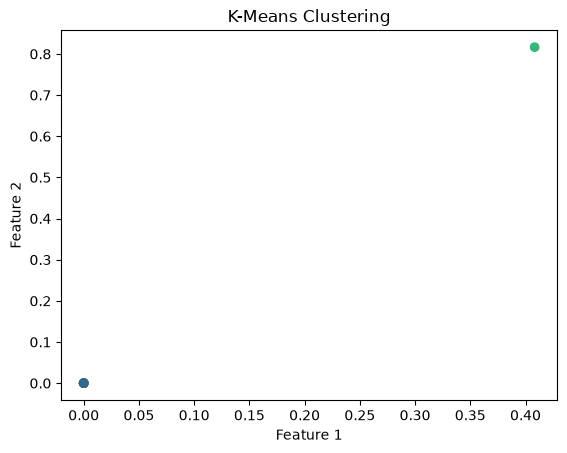

In [1]:
# Install if needed:
# !pip install pandas scikit-learn nltk matplotlib

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

nltk.download("stopwords")

# 1. Load dataset
df = pd.read_csv("f1db-continents.csv")
print(df.head())
print(df.columns)

# 2. Combine all text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 3. Clean text
stop = set(stopwords.words("english"))

def clean(x):
    x = re.sub(r"[^a-zA-Z\s]", " ", x.lower())
    return " ".join(w for w in x.split() if w not in stop)

df["text"] = df["text"].apply(clean)

# 4. NLP - TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df["text"])

# 5. K-Means
k = 4
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 6. Show results
print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())

print("\nClustered data:")
display(df[["text", "cluster"]].head(20))

# 7. Visualise
plt.scatter(
    X[:, 0].toarray(),
    X[:, 1].toarray(),
    c=df["cluster"]
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()

# 8. Save
df.to_csv("f1db-continents-clustered.csv", index=False)